           Model  Accuracy  Precision    Recall        F1
0       Logistic  0.664250   0.000000  0.000000  0.000000
1  Random Forest  0.633125   0.302694  0.071109  0.115164
2            SVM  0.664250   0.000000  0.000000  0.000000


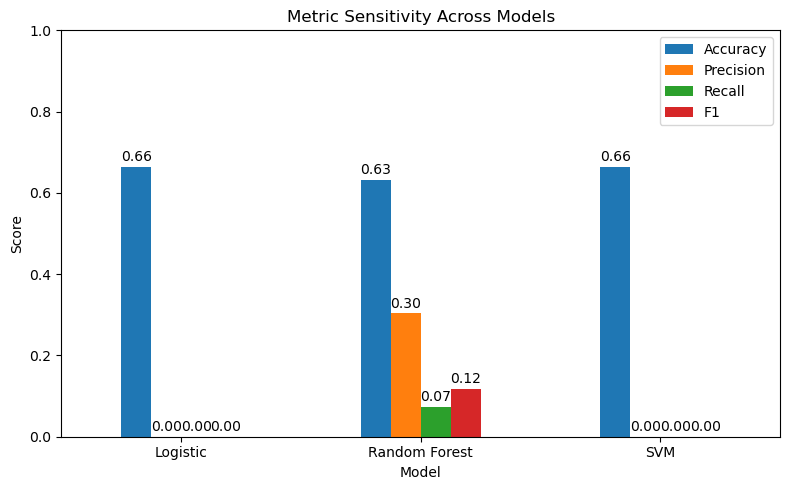

In [7]:
# ============================================
# RQ5: Metric Sensitivity (FINAL)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================
# 1. LOAD DATA
# ============================================

df = pd.read_csv('D:/University Of Europe/ML/Assignment 1/Cyber Security Attacks Dataset.csv')

target = 'Attack Type'

df = df.dropna()

# Convert to binary (same as before)
X = df.drop(columns=[target])
y = df[target]

top_class = y.value_counts().index[0]
y = (y == top_class).astype(int)

# Remove high-cardinality columns
threshold = 50
X = X.drop(columns=[col for col in X.columns if X[col].nunique() > threshold])

# Column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Encoder
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', encoder, cat_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# 2. MODELS (REQUIRED FIX)
# ============================================

models = {
    "Logistic": Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier())
    ]),
    
    "SVM": Pipeline([
        ('prep', preprocessor),
        ('model', SVC())
    ])
}

# ============================================
# 3. EVALUATE METRICS
# ============================================

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
    name,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0)
])

# ============================================
# 4. SAVE RESULTS
# ============================================

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print(df_results)

df_results.to_csv("RQ5_metrics.csv", index=False)

# ============================================
# 5. PLOT
# ============================================


ax = df_plot.plot(kind="bar", figsize=(8,5))

for container in ax.containers:
    labels = []
    for v in container.datavalues:
        if v == 0:
            labels.append("0.00")
        else:
            labels.append(f"{v:.2f}")
    ax.bar_label(container, labels=labels, padding=2)

plt.ylim(0, 1)
plt.title("Metric Sensitivity Across Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("RQ5_metrics_plot.pdf")
plt.show()